In [2]:
import os
os.chdir("C:/Users/David/OneDrive/Desktop/Actividades EBAC/10 Storytelling y casos de éxito/1 Storytelling/Entregable 6")

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("FACT_SALES.csv")
df

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5
...,...,...,...,...,...,...
121997,26-23,7501058792778BP1,1.192,150.829,4.000,TOTAL AUTOS SCANNING MEXICO
121998,26-23,7501058757630,1.947,235.416,2.797,TOTAL AUTOS SCANNING MEXICO
121999,26-23,7501058753441,18.013,429.289,9.102,TOTAL AUTOS SCANNING MEXICO
122000,26-23,7702626204208BP1,21.152,210.276,22.172,TOTAL AUTOS SCANNING MEXICO


In [6]:
# Eliminar registros de "TOTAL AUTOS AREA 5" para evitar duplicados

df_limpio = df[df["REGION"] != "TOTAL AUTOS AREA 5"].copy()

# Convertir WEEK a una fecha real

week_str = df_limpio["WEEK"].astype(str)
semana = week_str.str.split("-").str[0].str.zfill(2)
anio = "20" + week_str.str.split("-").str[1]

df_limpio["Fecha"] = pd.to_datetime(
    anio + "-W" + semana + "-1",
    format="%G-W%V-%u"
)

# Sumar ventas totales por semana (sumando todos los ITEM_CODE)

df_ventas_semanales = df_limpio.groupby("Fecha", as_index=False)["TOTAL_UNIT_SALES"].sum()
df_ventas_semanales = df_ventas_semanales.rename(columns={"TOTAL_UNIT_SALES": "Ventas_Totales"})

df_ventas_semanales

,Fecha,Ventas_Totales
0,2022-01-03,5113.238
1,2022-01-10,5118.212
2,2022-01-17,4362.458
3,2022-01-24,4312.795
4,2022-01-31,4516.053
...,...,...
75,2023-06-12,4555.047
76,2023-06-19,4419.386
77,2023-06-26,5347.834
78,2023-07-03,4830.567


In [8]:
# Cambio de índice princial

df_ventas_semanales.index = df_ventas_semanales["Fecha"]
df_ventas_semanales = df_ventas_semanales.drop(["Fecha"], axis = 1)
df_ventas_semanales

,Ventas_Totales
Fecha,
2022-01-03,5113.238
2022-01-10,5118.212
2022-01-17,4362.458
2022-01-24,4312.795
2022-01-31,4516.053
...,...
2023-06-12,4555.047
2023-06-19,4419.386
2023-06-26,5347.834


<Axes: xlabel='Fecha'>

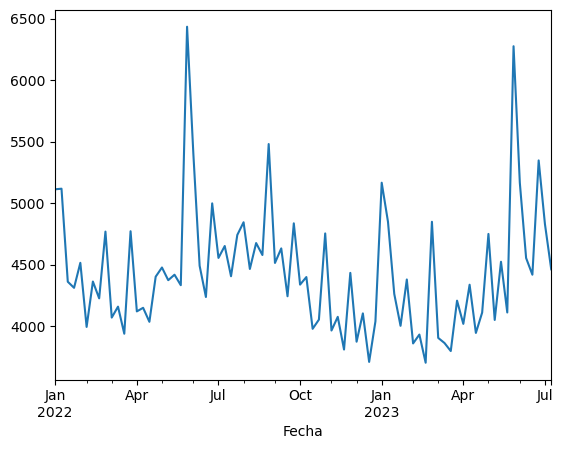

In [11]:
df_ventas_semanales["Ventas_Totales"].plot()

In [12]:
# Realizar la prueba Dickey-Fuller

from statsmodels.tsa.stattools import adfuller

result = adfuller(df_ventas_semanales["Ventas_Totales"])
print("El valor p de la prueba de Dickey-Fuller es: ", result[1])

El valor p de la prueba de Dickey-Fuller es:  0.5402105820538569


### Como el valor es mayor a 0.05 debemos asumir que la serie NO es estacionaria.

In [13]:
# Aplicar las primeras diferencias

df_ventas_semanales["temp_change"] = df_ventas_semanales["Ventas_Totales"].diff()
df_ventas_semanales

,Ventas_Totales,temp_change
Fecha,,
2022-01-03,5113.238,NaN
2022-01-10,5118.212,4.974
2022-01-17,4362.458,-755.754
2022-01-24,4312.795,-49.663
2022-01-31,4516.053,203.258
...,...,...
2023-06-12,4555.047,-610.410
2023-06-19,4419.386,-135.661
2023-06-26,5347.834,928.448


In [14]:
df_ventas_semanales = df_ventas_semanales.dropna()
df_ventas_semanales

,Ventas_Totales,temp_change
Fecha,,
2022-01-10,5118.212,4.974
2022-01-17,4362.458,-755.754
2022-01-24,4312.795,-49.663
2022-01-31,4516.053,203.258
2022-02-07,3995.196,-520.857
...,...,...
2023-06-12,4555.047,-610.410
2023-06-19,4419.386,-135.661
2023-06-26,5347.834,928.448


In [15]:
# Aplicación de la prueba de Dickey-Fuller sobre las diferencias (Como el valor es prácticamente 0 es muy bueno)

result2 = adfuller(df_ventas_semanales["temp_change"])
print("El valor p de la prueba de Dickey-Fuller es: ", result2[1])

El valor p de la prueba de Dickey-Fuller es:  0.07447548838308239


<Axes: xlabel='Fecha'>

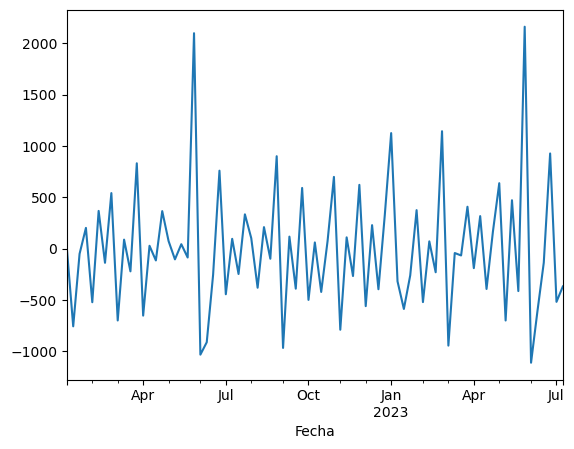

In [22]:
df_ventas_semanales["temp_change"].plot()

### Conclusión: La serie transformada de diferencias sí es estacionaria.

In [21]:
from statsmodels.tsa.arima.model import ARIMA

resultados_aic = {}

for p in range(0, 4):
    for d in [1]:  # ya sabemos que necesitas al menos d=1 por la prueba ADF
        for q in range(0, 4):
            try:
                modelo = ARIMA(df_ventas_semanales["Ventas_Totales"], order=(p, d, q))
                resultado = modelo.fit()
                resultados_aic[(p, d, q)] = resultado.aic
            except:
                continue

# Ordenar de menor a mayor AIC
mejor_modelo = sorted(resultados_aic.items(), key=lambda x: x[1])
print(mejor_modelo[:5])  # los 5 mejores modelos según AIC

C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was

[((3, 1, 0), np.float64(1186.5310085687154)), ((3, 1, 1), np.float64(1188.3671849543891)), ((3, 1, 2), np.float64(1190.105959443871)), ((2, 1, 3), np.float64(1190.2917980450304)), ((3, 1, 3), np.float64(1191.082842588356))]


C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


# Nos quedamos con ARIMA(3,1,0).

In [24]:
# Importación del módulo de ARIMA de statsmodels
from statsmodels.graphics.tsaplots import plot_predict

# Pronóstico de temperaturas usando un modelo ARIMA(3,1,0)

mod = ARIMA(df_ventas_semanales["Ventas_Totales"], order = (3,1,0))
res = mod.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:         Ventas_Totales   No. Observations:                   79
Model:                 ARIMA(3, 1, 0)   Log Likelihood                -589.266
Date:                Tue, 11 Aug 2026   AIC                           1186.531
Time:                        11:16:21   BIC                           1195.958
Sample:                    01-10-2022   HQIC                          1190.305
                         - 07-10-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6379      0.145     -4.395      0.000      -0.922      -0.353
ar.L2         -0.4963      0.140     -3.545      0.000      -0.771      -0.222
ar.L3         -0.4934      0.118     -4.195      0.0

C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\David\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


In [46]:
# Pronóstico puntual de las próximas 5 semanas

predicciones = res.forecast(5)
predicciones

2023-07-17    4496.248362
2023-07-24    4912.699952
2023-07-31    4811.877624
2023-08-07    4653.294443
2023-08-14    4599.031947
Freq: W-MON, Name: predicted_mean, dtype: float64

In [47]:
# Pronóstico por intervalo de las próximas 5 semanas

conf = res.get_forecast(5).conf_int(alpha=0.05)
conf

,lower Ventas_Totales,upper Ventas_Totales
2023-07-17,3601.383810,5391.112913
2023-07-24,3960.985893,5864.414011
2023-07-31,3829.362407,5794.392841
2023-08-07,3661.291533,5645.297353
2023-08-14,3475.935770,5722.128124


In [48]:
# Definición de grupos de prueba y entrenamiento

len_train = int(len(df_ventas_semanales) * 0.8)
len_test = int(len(df_ventas_semanales) * 0.2)

train = df_ventas_semanales[0:len_train]
test = df_ventas_semanales[len_train:]

In [49]:
test = pd.DataFrame(test)
predicciones = pd.DataFrame(predicciones)

test = test.reset_index()
predicciones = predicciones.reset_index()

In [50]:
predicciones = res.forecast(len(test))
predicciones

2023-07-17    4496.248362
2023-07-24    4912.699952
2023-07-31    4811.877624
2023-08-07    4653.294443
2023-08-14    4599.031947
2023-08-21    4762.089279
2023-08-28    4763.237695
2023-09-04    4708.356533
2023-09-11    4662.350362
2023-09-18    4718.368222
2023-09-25    4732.540328
2023-10-02    4718.397564
2023-10-09    4692.749332
2023-10-16    4709.137717
2023-10-23    4718.388913
2023-10-30    4717.008215
Freq: W-MON, Name: predicted_mean, dtype: float64

In [57]:
import numpy as np

n = len(test)
acumulador1 = 0
acumulador2 = 0

for contador in range(0, n):
    valor_test = test.iloc[contador, 1]
    valor_pred = predicciones.iloc[contador]
    acumulador1 += (valor_test - valor_pred)**2
    acumulador2 += np.abs((valor_test - valor_pred) / valor_test)

mse = acumulador1 / n
rmse = np.sqrt(mse)
mape = (acumulador2 / n) * 100

print(f"RMSE: {rmse}")
print(f"MAPE: {mape}%")

RMSE: 606.3618946112232
MAPE: 10.49242336798071%


In [61]:
# Predicción simple mediante promedios móviles

df_ventas_semanales.shape

(79, 2)

In [64]:
y_pred = df_ventas_semanales.copy()
y_pred = pd.DataFrame(y_pred)

In [67]:
y_pred['pronostico'] = df_ventas_semanales['Ventas_Totales'].rolling(30).mean()
y_pred.iloc[0:35]

,Ventas_Totales,temp_change,pronostico
Fecha,,,
2022-01-10,5118.212,4.974,NaN
2022-01-17,4362.458,-755.754,NaN
2022-01-24,4312.795,-49.663,NaN
2022-01-31,4516.053,203.258,NaN
2022-02-07,3995.196,-520.857,NaN
2022-02-14,4363.960,368.764,NaN
2022-02-21,4227.237,-136.723,NaN
2022-02-28,4769.636,542.399,NaN
2022-03-07,4071.079,-698.557,NaN


In [68]:
y_pred.tail()

,Ventas_Totales,temp_change,pronostico
Fecha,,,
2023-06-12,4555.047,-610.410,4287.317433
2023-06-19,4419.386,-135.661,4307.579300
2023-06-26,5347.834,928.448,4338.033233
2023-07-03,4830.567,-517.267,4369.878267
2023-07-10,4463.351,-367.216,4381.813233


In [73]:
import numpy as np

# Copia del DataFrame
y_pred_m = y_pred.copy()

# Desplazar la columna 'pronostico' 1 posición hacia abajo
y_pred_m['pronostico'] = y_pred_m['pronostico'].shift(1)

# Visualizar las primeras 35 filas
y_pred_m.iloc[0:35]

,Ventas_Totales,temp_change,pronostico
Fecha,,,
2022-01-10,5118.212,4.974,NaN
2022-01-17,4362.458,-755.754,NaN
2022-01-24,4312.795,-49.663,NaN
2022-01-31,4516.053,203.258,NaN
2022-02-07,3995.196,-520.857,NaN
2022-02-14,4363.960,368.764,NaN
2022-02-21,4227.237,-136.723,NaN
2022-02-28,4769.636,542.399,NaN
2022-03-07,4071.079,-698.557,NaN


In [80]:
# Seleccionar desde la fila 121 hasta el final usando .iloc
y_pred_m = df_ventas_semanales.copy()
y_pred_m['pronostico'] = y_pred_m['Ventas_Totales'].rolling(30).mean().shift(1)

# Quedarte solo con las filas correspondientes al periodo de test
y_pred_m = y_pred_m.iloc[-len(test):]
y_pred_m

,Ventas_Totales,temp_change,pronostico
Fecha,,,
2023-03-27,4208.578,409.354,4261.349867
2023-04-03,4019.885,-188.693,4218.935933
2023-04-10,4337.995,318.110,4202.436300
2023-04-17,3946.298,-391.697,4192.598667
2023-04-24,4111.807,165.509,4182.665367
2023-05-01,4750.662,638.855,4158.497500
2023-05-08,4051.863,-698.799,4172.227033
2023-05-15,4524.597,472.734,4160.611300
2023-05-22,4112.505,-412.092,4178.770033


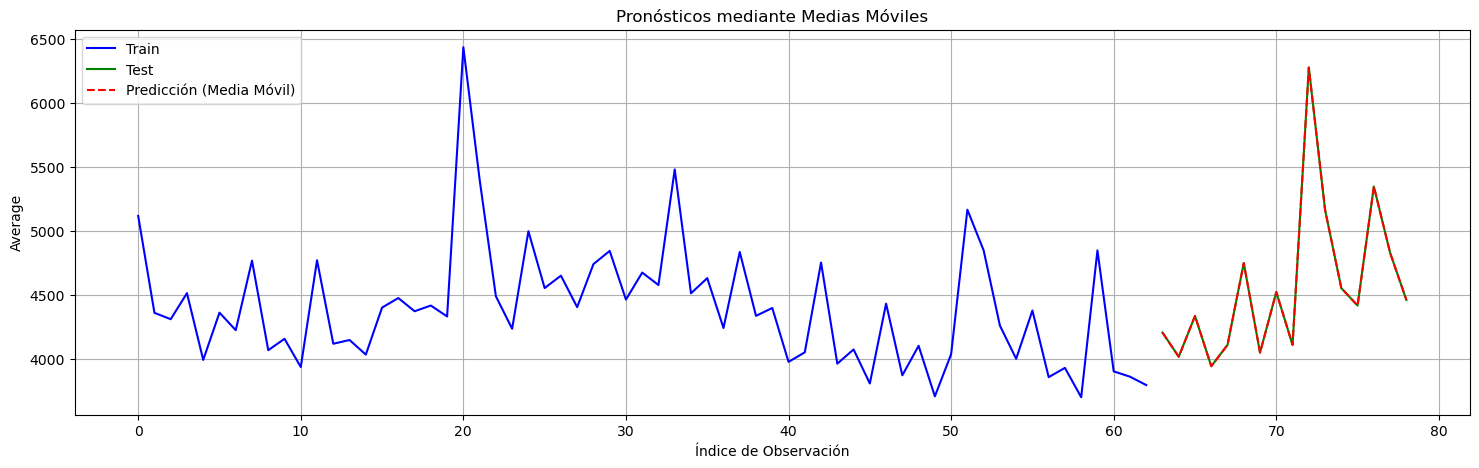

In [81]:
# Crear ejes X numéricos basados en el número de fila
x_train = np.arange(len(train))
x_test = np.arange(len(train), len(train) + len(test))

plt.figure(figsize=(18, 5))
plt.grid(True)

plt.plot(x_train, train['Ventas_Totales'].values, label="Train", color="blue")
plt.plot(x_test, test['Ventas_Totales'].values, label="Test", color="green")

y_pred_vals = y_pred_m.iloc[:, 0].values[-len(test):]
plt.plot(x_test[:len(y_pred_vals)], y_pred_vals, label="Predicción (Media Móvil)", color="red", linestyle="--")

plt.legend(loc="best")
plt.title("Pronósticos mediante Medias Móviles")
plt.xlabel("Índice de Observación")
plt.ylabel("Average")
plt.show()